# Econom-AI — Entrenamiento del clasificador de categorías

## Objetivo

Entrenar y comparar modelos capaces de predecir la categoría de una transacción a partir de su descripción:

```text
descripcion_modelo
        ↓
TF-IDF
        ↓
modelo de clasificación
        ↓
categoria predicha
```

En este notebook se comparan:

- Regresión Logística
- Complement Naive Bayes
- Linear SVM

La selección se realiza con `f1_macro` sobre el conjunto de validación

### ¿Por qué `f1_macro`?

Las categorías no tienen exactamente el mismo número de ejemplos. `f1_macro` calcula el F1 de cada categoría y luego obtiene un promedio simple, evitando que las clases grandes dominen la evaluación

### ¿Por qué Regresión Logística puede ser una buena opción para producción?

Además de clasificar, devuelve probabilidades mediante `predict_proba`. Esto permite reportar confianza y mostrar alternativas al usuario

In [1]:
# =========
# LIBRERÍAS
# =========

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    top_k_accuracy_score,
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 100)


## 1. Cargar el dataset

El dataset ya contiene una columna `split`. No usamos `train_test_split` porque las descripciones se separaron previamente por grupos para evitar fuga de información.


In [2]:
# ==============
# UBICAR DATASET
# ==============

def find_file(file_name):
    possible_paths = [
        Path("/content") / file_name,
        Path("/mnt/data") / file_name,
        Path(file_name),
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"No se encontró {file_name}. "
        "Ejecuta primero el notebook de preparación del dataset."
    )


DATASET_FILE = find_file("category_text_dataset_v1.csv")
OUTPUT_DIR = Path("/content") if Path("/content").exists() else Path("/mnt/data")

data_df = pd.read_csv(DATASET_FILE)

print("Archivo:", DATASET_FILE)
print("Dimensiones:", data_df.shape)
display(data_df.head())


Archivo: /content/category_text_dataset_v1.csv
Dimensiones: (748, 9)


,descripcion_modelo,descripcion_original,categoria,subcategoria,split,grupo_descripcion,origen,es_aumentada,texto_normalizado
0,Comida para perro,Comida para perro,Alimentación,Alimento para mascotas,test,18fed308d19c,transactions,False,comida para perro
1,cargo comida para perro,Comida para perro,Alimentación,Alimento para mascotas,test,18fed308d19c,transactions,True,cargo comida para perro
2,Comida para llevar,Comida para llevar,Alimentación,Comida rápida,test,3cd314b7d0e6,transactions,False,comida para llevar
3,cargo comida para llevar,Comida para llevar,Alimentación,Comida rápida,test,3cd314b7d0e6,transactions,True,cargo comida para llevar
4,Tienda de abarrotes,Tienda de abarrotes,Alimentación,Tiendas,test,bdcd4c77690c,transactions,False,tienda de abarrotes


## 2. Validaciones

Antes de entrenar comprobamos que:

- Existan `train`, `validation` y `test`
- Las once categorías estén presentes en cada split
- Una descripción base no aparezca en más de un conjunto
- No existan valores nulos


In [3]:
# ============
# VALIDACIONES
# ============

def validate(condition, message):
    if not condition:
        raise ValueError(message)


required_columns = {"descripcion_modelo","categoria","split","grupo_descripcion"}
missing_columns = required_columns - set(data_df.columns)

validate(not missing_columns,f"Faltan columnas: {sorted(missing_columns)}",)
validate(data_df.isna().sum().sum() == 0,"El dataset contiene valores nulos.")
validate(set(data_df["split"]) == {"train", "validation", "test"},"Los splits no son los esperados.")

group_split_count = (data_df.groupby("grupo_descripcion")["split"].nunique())
validate(group_split_count.max() == 1,"Una descripción base aparece en más de un split.")

categories_per_split = (data_df.groupby("split")["categoria"].nunique())
validate(categories_per_split.nunique() == 1,"Los splits no contienen el mismo número de categorías.")

print("Validaciones superadas.")
print()
print(data_df["split"].value_counts())

Validaciones superadas.

split
train         637
test           56
validation     55
Name: count, dtype: int64


In [4]:
# Distribución por categoría y split

distribution = (data_df.groupby(["categoria", "split"]).size().unstack(fill_value=0))
display(distribution)

split,test,train,validation
categoria,,,
Alimentación,6,79,6
Compras,6,75,6
Deudas,6,52,6
Educación,4,38,4
Entretenimiento,6,64,6
Finanzas,4,34,3
Otros,4,59,4
Salud,6,80,6
Servicios,4,45,4


## 3. Separar features y target

- El único feature del MVP es `descripcion_modelo`
- La variable objetivo es `categoria`
- No utilizamos `subcategoria`, `grupo_descripcion` ni los identificadores porque son columnas de auditoría, no información disponible para predecir


In [5]:
# ===============
# CREAR CONJUNTOS
# ===============

train_df = data_df[data_df["split"] == "train"].copy()
validation_df = data_df[data_df["split"] == "validation"].copy()
test_df = data_df[data_df["split"] == "test"].copy()

X_train = train_df["descripcion_modelo"]
y_train = train_df["categoria"]

X_validation = validation_df["descripcion_modelo"]
y_validation = validation_df["categoria"]

X_test = test_df["descripcion_modelo"]
y_test = test_df["categoria"]

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 637
Validation: 55
Test: 56


## 4. Representación TF-IDF

Se combinan dos representaciones:

### Palabras

```text
"pago de internet"
→ pago, internet, pago de, de internet
```

Ayuda a aprender términos y frases completas.

### Caracteres

```text
"tarjeta"
→ tar, arj, rje, ...
```

- Ayuda con abreviaturas, acentos, errores ortográficos y palabras poco frecuentes
- La combinación de palabras y caracteres suele ser útil para descripciones bancarias cortas

In [6]:
# ====================
# CONFIGURACIÓN TF-IDF
# ====================

def create_tfidf_features():
    return FeatureUnion([
        ("word_tfidf",TfidfVectorizer(lowercase=True,strip_accents="unicode",ngram_range=(1, 2),min_df=1,sublinear_tf=True)),
        ("char_tfidf",TfidfVectorizer(analyzer="char_wb",lowercase=True,strip_accents="unicode",ngram_range=(3, 5),min_df=1,sublinear_tf=True))
        ])

## 5. Modelos candidatos

Los tres modelos son adecuados como baseline para texto:

- **Regresión Logística:** rápida, interpretable y con probabilidades
- **Complement Naive Bayes:** baseline clásico para texto y clases desbalanceadas
- **Linear SVM:** suele funcionar muy bien con espacios TF-IDF de alta dimensión

`class_weight="balanced"` ayuda a que las categorías pequeñas tengan mayor peso durante el entrenamiento


In [7]:
# ===============
# DEFINIR MODELOS
# ===============

models = {"Logistic Regression": LogisticRegression(max_iter=2000,class_weight="balanced",C=4.0,random_state=SEED),
          "Complement Naive Bayes": ComplementNB(alpha=0.5,),"Linear SVM": LinearSVC(class_weight="balanced",C=1.0,random_state=SEED)}

In [8]:
# ===================
# ENTRENAR Y COMPARAR
# ===================

trained_models = {}
comparison_rows = []

for model_name, model in models.items():
    pipeline = Pipeline([("features", create_tfidf_features()),("model", model)])
    pipeline.fit(X_train, y_train)

    validation_prediction = pipeline.predict(X_validation)
    comparison_rows.append({
        "modelo": model_name,"accuracy_validation": accuracy_score(y_validation,validation_prediction),
        "precision_macro_validation": precision_score(y_validation,validation_prediction,average="macro",zero_division=0),
        "recall_macro_validation": recall_score(y_validation,validation_prediction,average="macro",zero_division=0),
        "f1_macro_validation": f1_score(y_validation,validation_prediction,average="macro",zero_division=0)
        })

    trained_models[model_name] = pipeline

comparison_df = (pd.DataFrame(comparison_rows).sort_values("f1_macro_validation",ascending=False,).reset_index(drop=True))
display(comparison_df.round(4))

,modelo,accuracy_validation,precision_macro_validation,recall_macro_validation,f1_macro_validation
0,Complement Naive Bayes,0.7273,0.8056,0.7197,0.6972
1,Logistic Regression,0.7455,0.7063,0.7121,0.6936
2,Linear SVM,0.7455,0.6851,0.7121,0.6900


## 6. Seleccionar el modelo

La selección se basa en `f1_macro_validation`.

Sin embargo, para el endpoint necesitamos probabilidades. Si Regresión Logística obtiene un resultado cercano al mejor modelo, tiene una ventaja práctica porque implementa `predict_proba` directamente.


In [9]:
# =========
# SELECCIÓN
# =========

best_validation_f1 = comparison_df.loc[0,"f1_macro_validation"]
logistic_f1 = comparison_df.loc[comparison_df["modelo"] == "Logistic Regression","f1_macro_validation"].iloc[0]

# Reglas:
# Si Logistic Regression está a menos de 0.03 del mejor, se prefiere por su soporte nativo de probabilidades

if best_validation_f1 - logistic_f1 <= 0.03: selected_model_name = "Logistic Regression"
else: selected_model_name = comparison_df.loc[0, "modelo"]
selected_model = trained_models[selected_model_name]

print("Modelo seleccionado:", selected_model_name)
print("F1 macro del mejor modelo:", round(best_validation_f1, 4))
print("F1 macro de Logistic Regression:", round(logistic_f1, 4))

Modelo seleccionado: Logistic Regression
F1 macro del mejor modelo: 0.6972
F1 macro de Logistic Regression: 0.6936


## 7. Evaluación final en test

El conjunto de test se utiliza una sola vez después de seleccionar el modelo. Así obtenemos una estimación más honesta del desempeño esperado en descripciones no vistas.


In [10]:
# ================
# MÉTRICAS DE TEST
# ================

test_prediction = selected_model.predict(X_test)

test_metrics = {
    "accuracy": accuracy_score(y_test,test_prediction),
    "precision_macro": precision_score(y_test,test_prediction,average="macro",zero_division=0),
    "recall_macro": recall_score(y_test,test_prediction,average="macro",zero_division=0),
    "f1_macro": f1_score(y_test,test_prediction,average="macro",zero_division=0)
}

display(pd.DataFrame([test_metrics],index=[selected_model_name]).round(4))

,accuracy,precision_macro,recall_macro,f1_macro
Logistic Regression,0.7679,0.7013,0.7576,0.7148


In [11]:
# Reporte por categoría

report_df = pd.DataFrame(classification_report(y_test,test_prediction,output_dict=True,zero_division=0)).transpose()
display(report_df.round(4))

,precision,recall,f1-score,support
Alimentación,0.6000,1.0000,0.7500,6.0000
Compras,1.0000,0.6667,0.8000,6.0000
Deudas,1.0000,1.0000,1.0000,6.0000
Educación,0.0000,0.0000,0.0000,4.0000
Entretenimiento,0.8571,1.0000,0.9231,6.0000
Finanzas,1.0000,1.0000,1.0000,4.0000
Otros,0.6667,1.0000,0.8000,4.0000
Salud,0.8571,1.0000,0.9231,6.0000
Servicios,0.4000,0.5000,0.4444,4.0000
Transporte,0.3333,0.1667,0.2222,6.0000


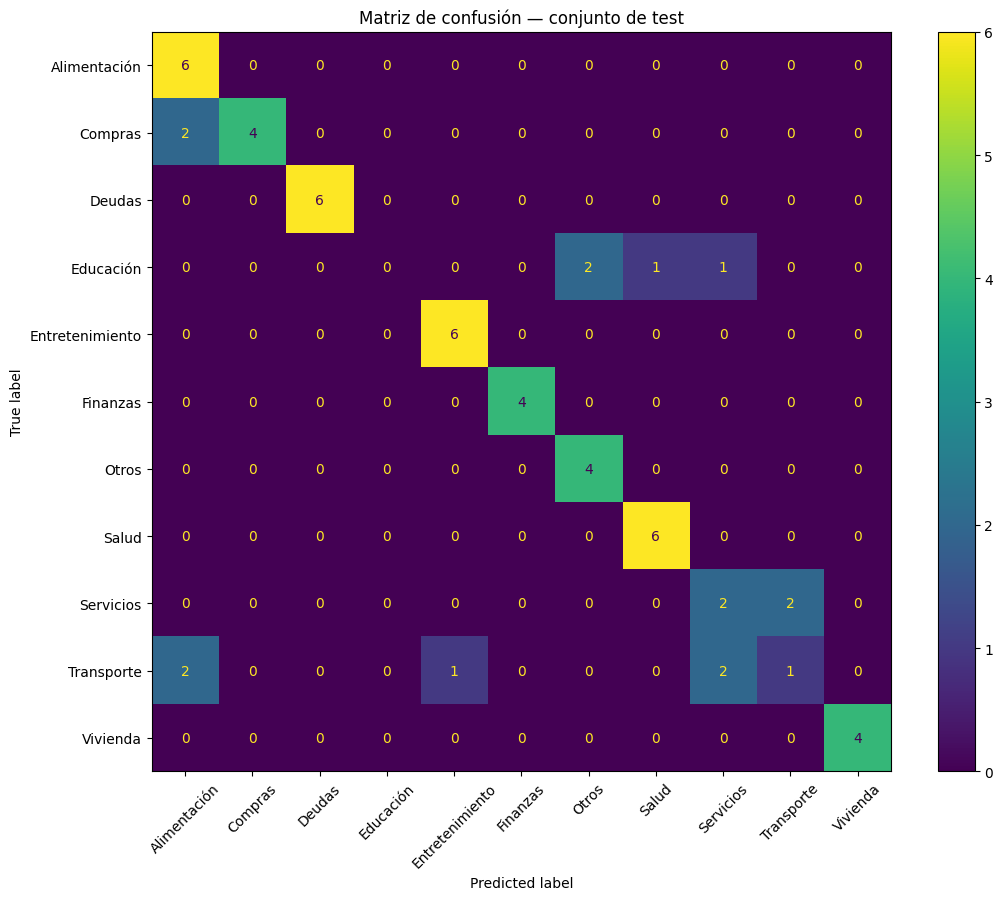

In [12]:
# Matriz de confusión

labels = sorted(y_test.unique())

confusion = confusion_matrix(y_test,test_prediction,labels=labels)
figure, axis = plt.subplots(figsize=(11, 9))
display_matrix = ConfusionMatrixDisplay(confusion_matrix=confusion,display_labels=labels)
display_matrix.plot(ax=axis,xticks_rotation=45,values_format="d")

plt.title("Matriz de confusión — conjunto de test")
plt.tight_layout()
plt.show()

## 8. Probabilidades y Top 3

Esta sección se ejecuta cuando el modelo seleccionado admite `predict_proba`. La precisión Top 3 considera correcta una predicción cuando la categoría real aparece entre las tres alternativas con mayor probabilidad.

In [13]:
# ==============
# PROBABILIDADES
# ==============

if hasattr(selected_model, "predict_proba"):
    test_probabilities = selected_model.predict_proba(X_test)
    classes = selected_model.classes_
    test_metrics["top_3_accuracy"] = top_k_accuracy_score(y_test,test_probabilities,k=3,labels=classes)
    confidence = test_probabilities.max(axis=1)

    print("Top 3 accuracy:",round(test_metrics["top_3_accuracy"], 4))
    print("Confianza promedio:",round(confidence.mean(), 4))
else:
    test_probabilities = None
    classes = None
    confidence = np.full(len(X_test), np.nan)

    print("El modelo seleccionado no implementa predict_proba.")

Top 3 accuracy: 0.8214
Confianza promedio: 0.5884


## 9. Umbral de revisión manual

Una confianza baja no significa necesariamente que la predicción sea incorrecta, pero indica que el modelo está menos seguro.

Para el MVP se calcula una tabla de cobertura:

- `cobertura`: porcentaje de movimientos aceptados automáticamente;
- `precision_aceptada`: precisión dentro de los movimientos que superan el umbral.

No se fija un umbral definitivo sin revisar esta tabla.


In [14]:
# =================
# TABLA DE UMBRALES
# =================

threshold_table = pd.DataFrame()

if test_probabilities is not None:
    correct_prediction = (test_prediction == y_test.to_numpy())
    threshold_rows = []

    for threshold in np.arange(0.35, 0.91, 0.05):
        accepted = confidence >= threshold

        threshold_rows.append({
            "umbral": round(float(threshold), 2),
            "cobertura": accepted.mean(),
            "registros_aceptados": accepted.sum(),
            "precision_aceptada": (correct_prediction[accepted].mean()
                if accepted.any()
                else np.nan
            )})

    threshold_table = pd.DataFrame(threshold_rows)
    display(threshold_table.round(4))

,umbral,cobertura,registros_aceptados,precision_aceptada
0,0.35,0.6786,38,0.8947
1,0.40,0.6607,37,0.8919
2,0.45,0.6071,34,0.9118
3,0.50,0.5357,30,0.9333
4,0.55,0.5357,30,0.9333
5,0.60,0.5179,29,0.9310
6,0.65,0.4821,27,0.9259
7,0.70,0.4821,27,0.9259
8,0.75,0.4286,24,0.9583
9,0.80,0.3750,21,1.0000


## 10. Análisis de errores

Es importante revisar qué frases fallan. Las métricas muestran cuánto falla el modelo; el análisis de errores ayuda a entender por qué.


In [19]:
# ====================
# PREDICCIONES DE TEST
# ====================

test_results_df = test_df[
    ["descripcion_modelo","descripcion_original","categoria","subcategoria","grupo_descripcion"]].copy()

test_results_df = test_results_df.rename(columns={"categoria": "categoria_real"})
test_results_df["categoria_predicha"] = test_prediction
test_results_df["confianza"] = confidence
test_results_df["es_correcta"] = (test_results_df["categoria_real"] == test_results_df["categoria_predicha"])
errors_df = test_results_df[~test_results_df["es_correcta"]].sort_values("confianza", ascending=False)

print("Errores encontrados:", len(errors_df))
display(errors_df)

Errores encontrados: 13


,descripcion_modelo,descripcion_original,categoria_real,subcategoria,grupo_descripcion,categoria_predicha,confianza,es_correcta
10,ropa en tienda,ropa en tienda,Compras,Ropa,ef15f6501962,Alimentación,0.789051,False
11,cargo ropa en tienda,ropa en tienda,Compras,Ropa,ef15f6501962,Alimentación,0.746459,False
20,Papelería,Papelería,Educación,Papelería,25d6432362f6,Otros,0.452067,False
21,cargo papelería,Papelería,Educación,Papelería,25d6432362f6,Otros,0.413135,False
50,pasaje de camión,pasaje de camión,Transporte,Autobús,c3deaa4d112d,Servicios,0.316842,False
44,servicio de televisión,servicio de televisión,Servicios,TV de paga,410d3807ecfd,Transporte,0.314118,False
18,libros de estudio,libros de estudio,Educación,Material escolar,1c5cf03667b7,Servicios,0.275297,False
45,serv de televisión,servicio de televisión,Servicios,TV de paga,410d3807ecfd,Transporte,0.209467,False
46,Combustible,Combustible,Transporte,Combustible,12c106cc092d,Alimentación,0.192658,False
51,cargo pasaje de camión,pasaje de camión,Transporte,Autobús,c3deaa4d112d,Servicios,0.183770,False


## 11. Función de predicción

La función devuelve:

- categoría principal;
- confianza;
- tres alternativas;
- indicador de revisión.

El umbral usado aquí es demostrativo y deberá ajustarse con los resultados de validación y las necesidades del producto.


In [20]:
# ========================
# FUNCIÓN PARA EL ENDPOINT
# ========================

REVIEW_THRESHOLD = 0.60


def predict_category(description, top_k=3):
    if not isinstance(description, str): raise TypeError("La descripción debe ser texto.")

    clean_description = description.strip()

    if not clean_description: raise ValueError("La descripción no puede estar vacía.")

    predicted_category = selected_model.predict([clean_description])[0]

    result = {
        "descripcion": clean_description,
        "categoria_predicha": predicted_category,
        "modelo_version": "category-classifier-v1",
    }

    if hasattr(selected_model, "predict_proba"):
        probabilities = selected_model.predict_proba([clean_description])[0]
        classes = selected_model.classes_
        top_indices = np.argsort(probabilities)[::-1][:top_k]
        alternatives = [{"categoria": classes[index],"probabilidad": round(float(probabilities[index]),4)}
            for index in top_indices
        ]

        confidence_value = float(probabilities[top_indices[0]])
        result["confianza"] = round(confidence_value,4,)
        result["requiere_revision"] = (confidence_value < REVIEW_THRESHOLD)
        result["alternativas"] = alternatives

    return result


examples = [
    "pago mensual de internet",
    "uber a la oficina",
    "abono a tdc",
    "transferencia a ahorro",
]

for example in examples: print(predict_category(example))

{'descripcion': 'pago mensual de internet', 'categoria_predicha': 'Servicios', 'modelo_version': 'category-classifier-v1', 'confianza': 0.873, 'requiere_revision': False, 'alternativas': [{'categoria': 'Servicios', 'probabilidad': 0.873}, {'categoria': 'Deudas', 'probabilidad': 0.0401}, {'categoria': 'Otros', 'probabilidad': 0.0134}]}
{'descripcion': 'uber a la oficina', 'categoria_predicha': 'Transporte', 'modelo_version': 'category-classifier-v1', 'confianza': 0.8918, 'requiere_revision': False, 'alternativas': [{'categoria': 'Transporte', 'probabilidad': 0.8918}, {'categoria': 'Salud', 'probabilidad': 0.0169}, {'categoria': 'Entretenimiento', 'probabilidad': 0.0148}]}
{'descripcion': 'abono a tdc', 'categoria_predicha': 'Deudas', 'modelo_version': 'category-classifier-v1', 'confianza': 0.9552, 'requiere_revision': False, 'alternativas': [{'categoria': 'Deudas', 'probabilidad': 0.9552}, {'categoria': 'Salud', 'probabilidad': 0.0065}, {'categoria': 'Otros', 'probabilidad': 0.0054}]}
{

## 12. Entrenamiento final y exportación

- Después de evaluar el modelo, se vuelve a entrenar con `train + validation`
- El conjunto de test no se incorpora para conservarlo como referencia independiente de evaluación.

Se guarda el pipeline completo. El archivo incluye:

```text
TF-IDF de palabras
+
TF-IDF de caracteres
+
clasificador
```

Por eso FastAPI solo necesitará cargar un archivo `.joblib`

In [21]:
# ===================
# ENTRENAMIENTO FINAL
# ===================

train_validation_df = data_df[data_df["split"].isin(["train", "validation"])].copy()
X_train_final = train_validation_df["descripcion_modelo"]
y_train_final = train_validation_df["categoria"]

# Para la versión de producción se conserva la misma familia de modelo seleccionada
if selected_model_name == "Logistic Regression":
    final_estimator = LogisticRegression(max_iter=2000,class_weight="balanced",C=4.0,random_state=SEED)
elif selected_model_name == "Complement Naive Bayes": final_estimator = ComplementNB(alpha=0.5)
else: final_estimator = LinearSVC(class_weight="balanced",C=1.0,random_state=SEED)

final_model = Pipeline([("features", create_tfidf_features()),("model", final_estimator)])
final_model.fit(X_train_final,y_train_final)

print("Modelo final entrenado con:",len(train_validation_df),"registros.")

Modelo final entrenado con: 692 registros.


In [22]:
# ===================
# EXPORTAR ARTEFACTOS
# ===================

MODEL_PATH = OUTPUT_DIR / "category_classifier_v1.joblib"
METRICS_PATH = OUTPUT_DIR / "category_classifier_metrics_v1.json"
PREDICTIONS_PATH = OUTPUT_DIR / "category_classifier_test_predictions_v1.csv"
COMPARISON_PATH = OUTPUT_DIR / "category_model_comparison_v1.csv"

joblib.dump(final_model,MODEL_PATH)
comparison_df.to_csv(COMPARISON_PATH,index=False,encoding="utf-8-sig")
test_results_df.to_csv(PREDICTIONS_PATH,index=False,encoding="utf-8-sig")

metadata = {
    "model_version": "category-classifier-v1",
    "model_name": selected_model_name,
    "feature": "descripcion_modelo",
    "target": "categoria",
    "classes": sorted(data_df["categoria"].unique().tolist()),
    "review_threshold_demo": REVIEW_THRESHOLD,
    "validation_selection_metric": "f1_macro",
    "test_metrics": {key: round(float(value), 6)for key, value in test_metrics.items()},
    "dataset_rows": int(len(data_df)),
    "train_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "test_rows": int(len(test_df))
}

with open(METRICS_PATH,"w",encoding="utf-8",) as file:json.dump(metadata,file,ensure_ascii=False,indent=2)

print("Archivos generados:")
print(MODEL_PATH)
print(METRICS_PATH)
print(PREDICTIONS_PATH)
print(COMPARISON_PATH)

Archivos generados:
/content/category_classifier_v1.joblib
/content/category_classifier_metrics_v1.json
/content/category_classifier_test_predictions_v1.csv
/content/category_model_comparison_v1.csv


## Resultado

Con este notebook queda terminada la primera versión del clasificador.

El siguiente paso será crear el microservicio FastAPI con:

```text
GET  /health
POST /predict/category
```

El endpoint cargará `category_classifier_v1.joblib` y reutilizará la misma estructura de respuesta definida en `predict_category`.
